# Logistic regression

## Importación de librerías y paquetes y definición de constantes

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle


## Recopilación de datos

In [ ]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/bank-marketing-campaign-data.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Un primer paso sería descubrir que significa cada variable(columna), indagando por internet obtenemos:

| Variable        | Descripción                                                                 |
|----------------|------------------------------------------------------------------------------|
| age            | Edad del cliente                                                            |
| job            | Tipo de trabajo o profesión del cliente                                     |
| marital        | Estado civil del cliente (soltero, casado, etc.)                            |
| education      | Nivel educativo del cliente                                                 |
| default        | Indica si el cliente tiene deuda por impago (default de crédito) (sí/no)    |
| housing        | Indica si el cliente tiene un préstamo hipotecario (sí/no)                  |
| loan           | Indica si el cliente tiene un préstamo personal (sí/no)                     |
| contact        | Tipo de comunicación usada para contactar al cliente                        |
| month          | Mes en que se realizó el último contacto                                    |
| day_of_week    | Día de la semana en que se realizó el último contacto                       |
| duration       | Duración de la última llamada (en segundos)                                 |
| campaign       | Número de contactos realizados durante esta campaña para este cliente       |
| pdays          | Número de días desde el último contacto con el cliente (-1: no contactado)  |
| previous       | Número de contactos realizados antes de esta campaña                        |
| poutcome       | Resultado de la campaña anterior (success, failure, other, unknown)         |
| emp.var.rate   | Tasa de variación del empleo trimestral                                     |
| cons.price.idx | Índice de precios al consumidor                                              |
| cons.conf.idx  | Índice de confianza del consumidor                                           |
| euribor3m      | Tasa Euribor a 3 meses (referencia financiera)                              |
| nr.employed    | Número de empleados (datos del sector bancario o país)                      |
| y              | Variable objetivo: indica si el cliente contrató el producto (sí/no)        |


## Análisis descriptivo 

In [25]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [26]:
df.shape

(41188, 21)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [28]:
df.nunique()

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [29]:
df.duplicated().sum()

np.int64(12)

### Hay 12 filas duplicadas, asi que nos aseguramos de no dejar duplicados en todo el dataset

In [30]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(41176, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [31]:
df.duplicated().sum()

np.int64(0)

### Valores nulos o faltantes:

In [32]:
df.isnull().sum().sort_values(ascending=False) / len(df)

age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64

#### No hay valores nulos

In [33]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


### Limpieza de datos: Eliminar información irrelevante
    
Decido eliminar variables redundantes y que no aportan información destacada, en este caso: 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'month', 'day_of_week', 'duration', 'marital', 'education'

In [34]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [35]:
df.drop(['marital', 'education', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
          'nr.employed', 'contact', 'month','day_of_week', 'duration' ], axis = 1, inplace = True)
df.head()

C:\Users\Simón\AppData\Local\Temp\ipykernel_14312\1875047082.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['marital', 'education', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',


,age,job,default,housing,loan,campaign,pdays,previous,poutcome,y
0,56,housemaid,no,no,no,1,999,0,nonexistent,no
1,57,services,unknown,no,no,1,999,0,nonexistent,no
2,37,services,no,yes,no,1,999,0,nonexistent,no
3,40,admin.,no,no,no,1,999,0,nonexistent,no
4,56,services,no,no,yes,1,999,0,nonexistent,no


In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.0,32.0,38.0,47.0,98.0
campaign,41176.0,2.567879,2.770318,1.0,1.0,2.0,3.0,56.0
pdays,41176.0,962.464810,186.937102,0.0,999.0,999.0,999.0,999.0
previous,41176.0,0.173013,0.494964,0.0,0.0,0.0,0.0,7.0


## Análisis de variables:

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       41176 non-null  int64 
 1   job       41176 non-null  object
 2   default   41176 non-null  object
 3   housing   41176 non-null  object
 4   loan      41176 non-null  object
 5   campaign  41176 non-null  int64 
 6   pdays     41176 non-null  int64 
 7   previous  41176 non-null  int64 
 8   poutcome  41176 non-null  object
 9   y         41176 non-null  object
dtypes: int64(4), object(6)
memory usage: 3.5+ MB


### Variables univariante: variables categóricas

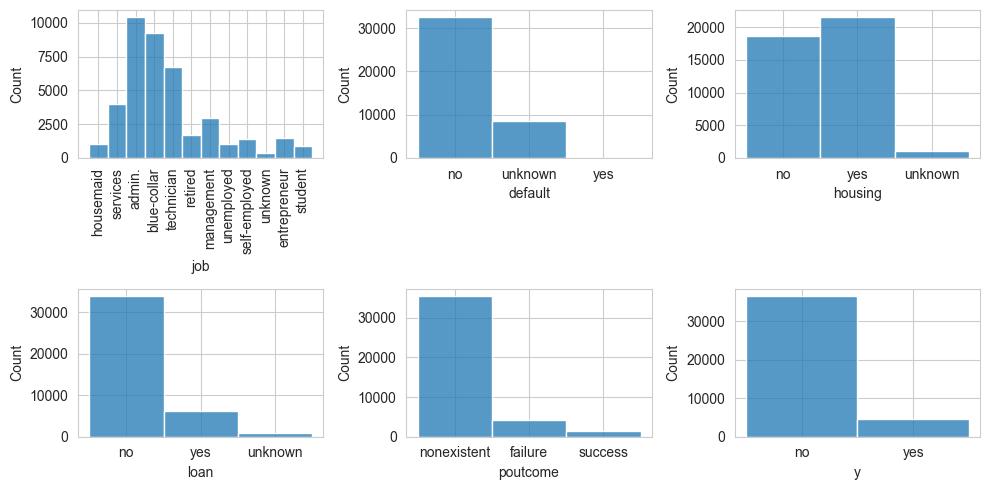

In [38]:
fig, axis = plt.subplots(2, 3, figsize=(10, 5))
sns.set_style("whitegrid")
axis[0,0].tick_params(axis='x', rotation=90)
sns.histplot(ax=axis[0,0], data=df, x="job")
sns.histplot(ax=axis[0,1], data=df, x="default")
sns.histplot(ax=axis[0,2], data=df, x="housing")
sns.histplot(ax=axis[1,0], data=df, x="loan")
sns.histplot(ax=axis[1,1], data=df, x="poutcome")
sns.histplot(ax=axis[1,2], data=df, x="y")
plt.tight_layout()
plt.show()

### Variables univariante: variables númericas

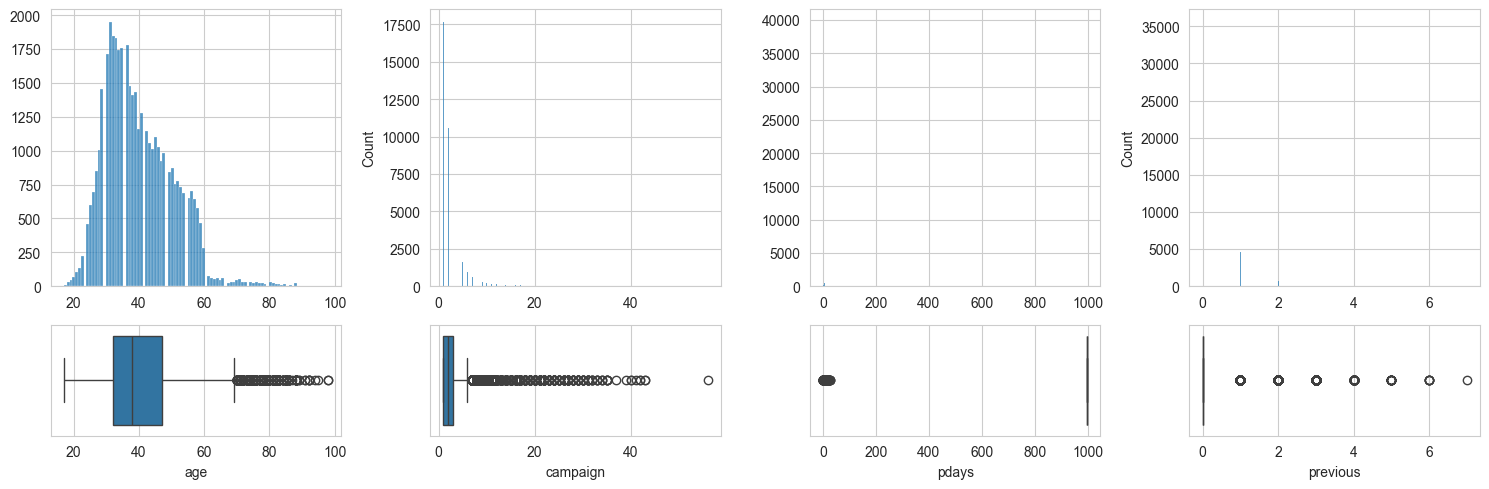

In [39]:
fig, axis = plt.subplots(2, 4, figsize=(15, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="age").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="age")
sns.histplot(ax=axis[0, 1], data=df, x="campaign").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="campaign")
sns.histplot(ax=axis[0, 2], data=df, x="pdays").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="pdays")
sns.histplot(ax=axis[0, 3], data=df, x="previous").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="previous")


plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener claro las variables que cuentan con valores atípicos.

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

### Codificación de variables categóricas para el estudio de correlaciones, análisis númerico-categórico

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       41176 non-null  int64 
 1   job       41176 non-null  object
 2   default   41176 non-null  object
 3   housing   41176 non-null  object
 4   loan      41176 non-null  object
 5   campaign  41176 non-null  int64 
 6   pdays     41176 non-null  int64 
 7   previous  41176 non-null  int64 
 8   poutcome  41176 non-null  object
 9   y         41176 non-null  object
dtypes: int64(4), object(6)
memory usage: 3.5+ MB


In [46]:
df["job_n"] = pd.factorize(df["job"])[0]
df["default_n"] = pd.factorize(df["default"])[0]
df["housing_n"] = pd.factorize(df["housing"])[0]
df["loan_n"] = pd.factorize(df["loan"])[0]
df["poutcome_n"] = pd.factorize(df["poutcome"])[0]
df["y_n"] = pd.factorize(df["y"])[0]

C:\Users\Simón\AppData\Local\Temp\ipykernel_14312\3472581447.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["job_n"] = pd.factorize(df["job"])[0]
C:\Users\Simón\AppData\Local\Temp\ipykernel_14312\3472581447.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["default_n"] = pd.factorize(df["default"])[0]
C:\Users\Simón\AppData\Local\Temp\ipykernel_14312\3472581447.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

In [43]:
df.columns

Index(['age', 'job', 'default', 'housing', 'loan', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'job_n', 'default_n', 'housing_n',
       'loan_n', 'poutcome_n', 'y_n'],
      dtype='object')

| Variable        | Descripción                                                                 |
|----------------|------------------------------------------------------------------------------|
| age            | Edad del cliente                                                            |
| job            | Tipo de trabajo o profesión del cliente                                     |
| default        | Indica si el cliente tiene deuda por impago (default de crédito) (sí/no)    |
| housing        | Indica si el cliente tiene un préstamo hipotecario (sí/no)                  |
| loan           | Indica si el cliente tiene un préstamo personal (sí/no)                     |
| campaign       | Número de contactos realizados durante esta campaña para este cliente       |
| pdays          | Número de días desde el último contacto con el cliente (-1: no contactado)  |
| previous       | Número de contactos realizados antes de esta campaña                        |
| poutcome       | Resultado de la campaña anterior (success, failure, other, unknown)         |
| y              | Variable objetivo: indica si el cliente contrató el producto (sí/no)        |


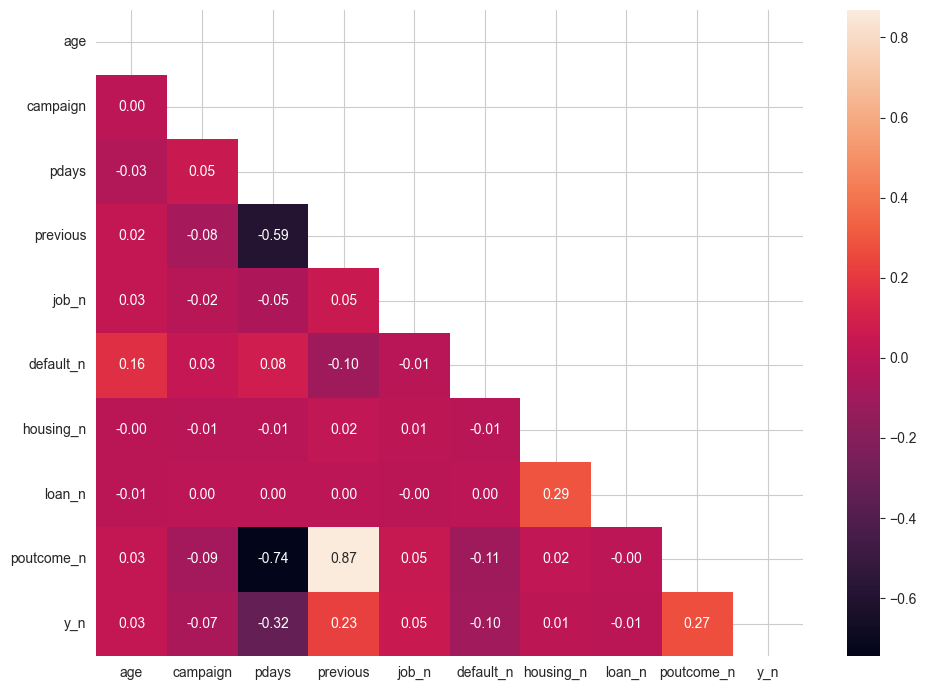

In [ ]:
corr = df[['age', 'campaign', 'pdays', 'previous',
           'job_n', 'default_n', 'housing_n',
           'loan_n', 'poutcome_n', 'y_n']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

### Observaciones:
Distintas correlaciones a tener en cuenta: age-default, pdays-(y, poutcome, previous), previous-(y, poutcome), housing-loan, poutcome-y.

Procedemos a estudiar de forma detallada las correlaciones para sacar una conclusión

 

### Análisis de variables multivariante: númerico-númerico

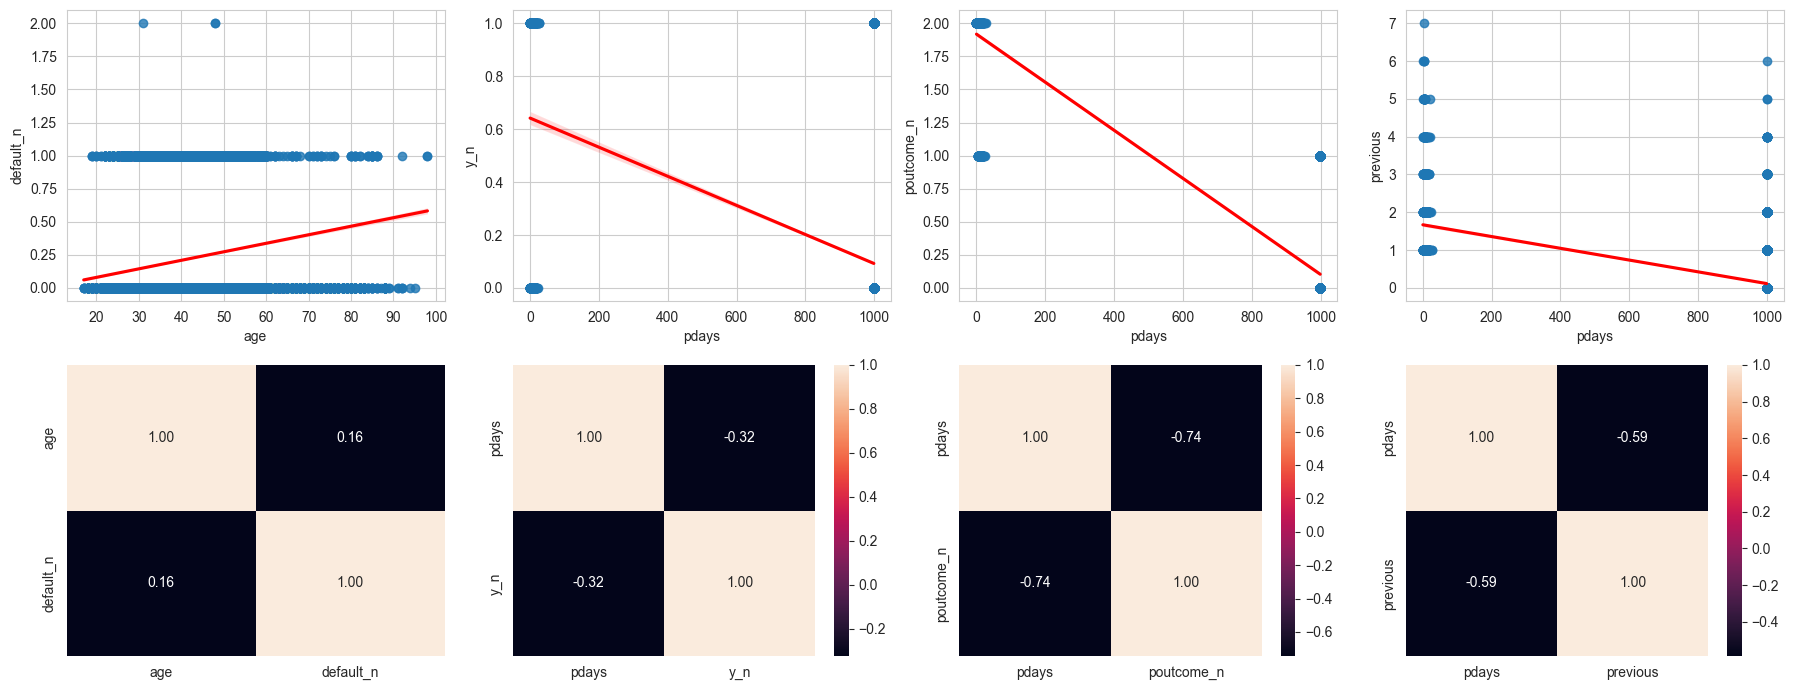

In [48]:
corr_age_default = df[["age", "default_n"]].corr()
corr_pdays_y = df[["pdays", "y_n"]].corr()
corr_pdays_poutcome = df[["pdays", "poutcome_n"]].corr()
corr_pdays_previous = df[["pdays", "previous"]].corr()

fig, axis = plt.subplots(2, 4, figsize=(18, 7))
sns.set_style("whitegrid")

sns.regplot(ax=axis[0, 0], data=df, x="age", y="default_n", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1, 0], data=corr_age_default, annot=True, fmt=".2f", cbar=False)

sns.regplot(ax=axis[0, 1], data=df, x="pdays", y="y_n", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1, 1], data=corr_pdays_y, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 2], data=df, x="pdays", y="poutcome_n", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1, 2], data=corr_pdays_poutcome, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 3], data=df, x="pdays", y="previous", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1, 3], data=corr_pdays_previous, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

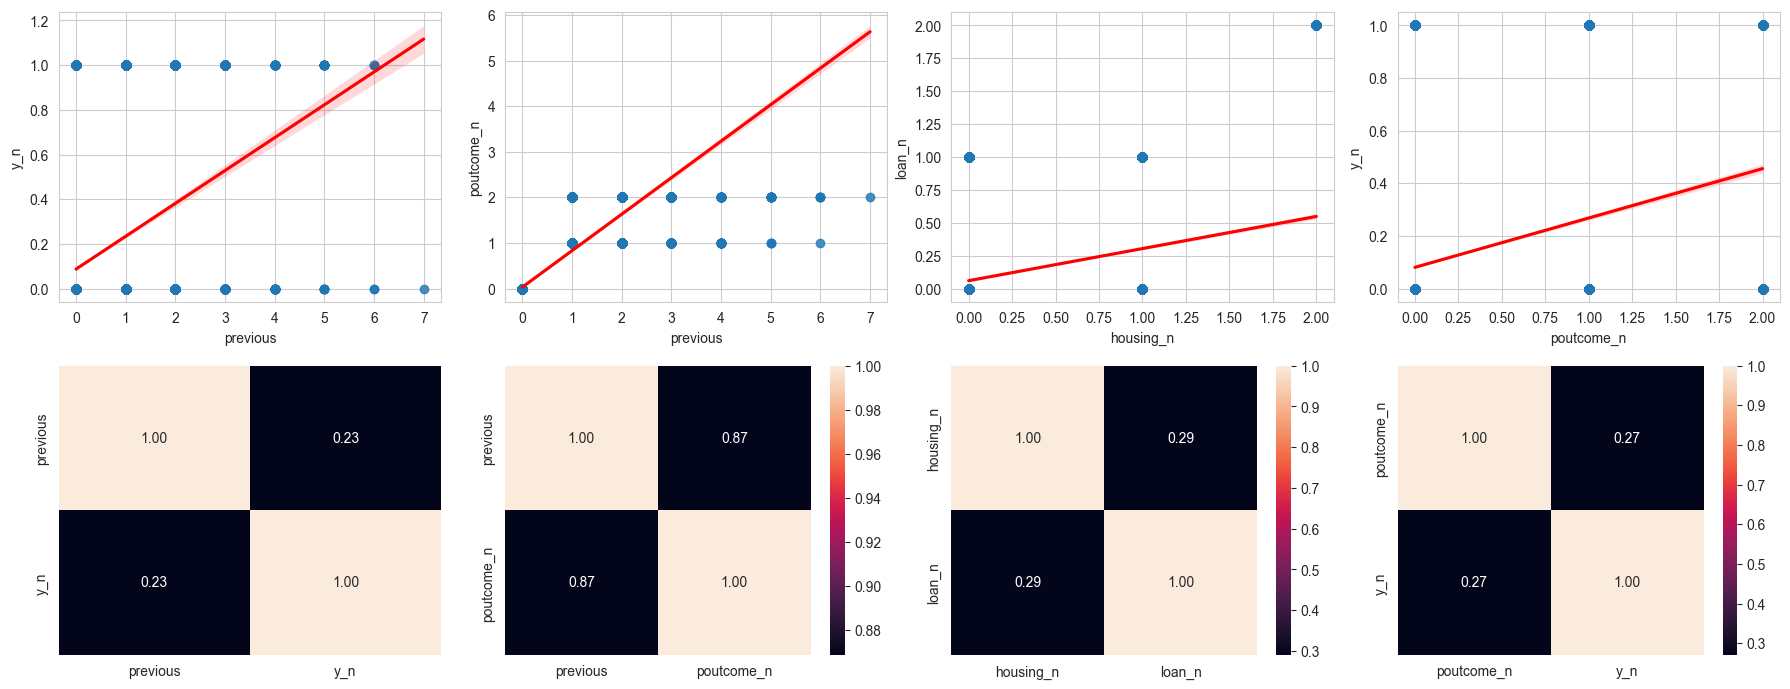

In [50]:
corr_previous_y = df[["previous", "y_n"]].corr()
corr_previous_poutcome = df[["previous", "poutcome_n"]].corr()
corr_housing_loan = df[["housing_n", "loan_n"]].corr()
corr_poutcome_y = df[["poutcome_n", "y_n"]].corr()

fig, axis = plt.subplots(2, 4, figsize=(18, 7))
sns.set_style("whitegrid")

sns.regplot(ax=axis[0, 0], data=df, x="previous", y="y_n", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1, 0], data=corr_previous_y, annot=True, fmt=".2f", cbar=False)

sns.regplot(ax=axis[0, 1], data=df, x="previous", y="poutcome_n", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1, 1], data=corr_previous_poutcome, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 2], data=df, x="housing_n", y="loan_n", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1, 2], data=corr_housing_loan, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 3], data=df, x="poutcome_n", y="y_n", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1, 3], data=corr_poutcome_y, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

### Observaciones:
1. Hay mayor cantidad de viviendas tipo 1(entire home) y también son las que alcanzan un precio más elevado, seguidas por las tipo 0(private room) y luego las tipo 2 (shared room).
2. Hay viviendas más caras en una franja de longitud, por debajo de los 1000$ se distribuyen por toda la ciudad.
3. El último gráfico no aporta mucha información, esxisten 2 propietarios con un gran número de viviendas, seguramente inmobiliarias, con disponibilidad muy variada.

### Análisis de variables multivariante: categórico-categórico

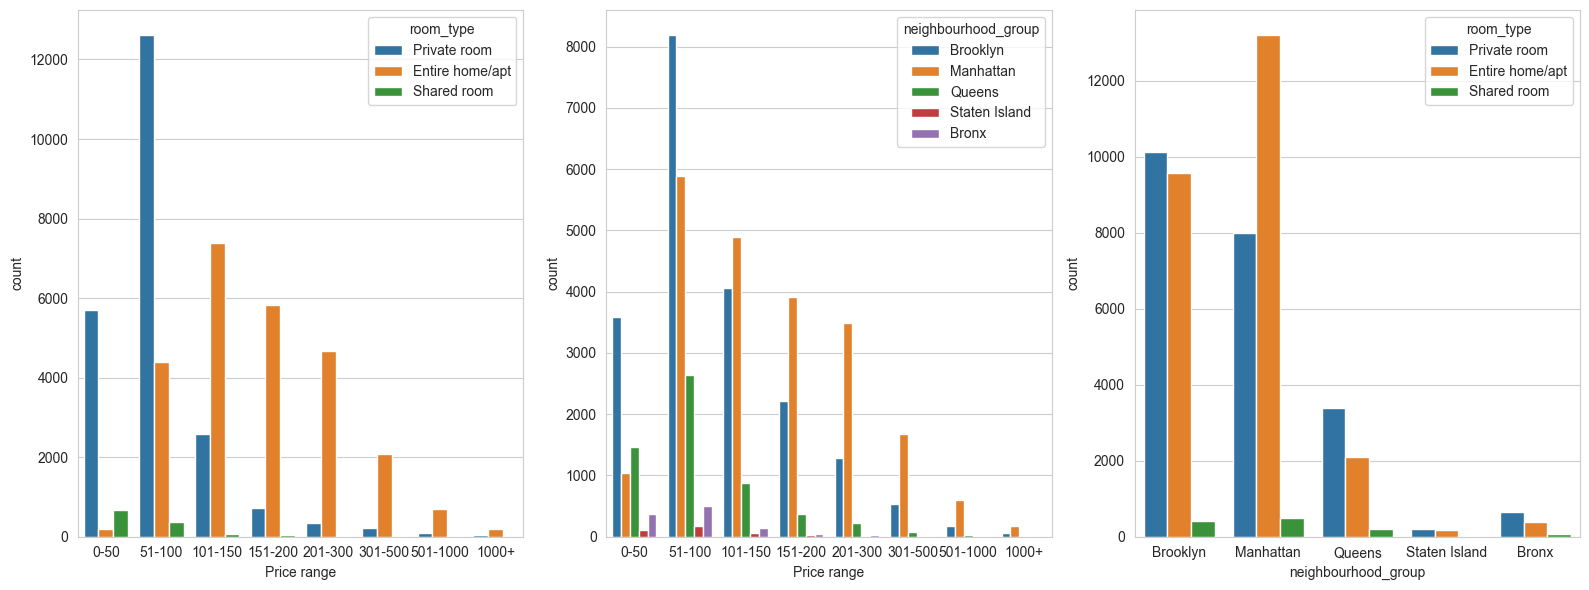

In [ ]:
fig, axis = plt.subplots(1, 3, figsize=(16, 6))
bins = [0, 50, 100, 150, 200, 300, 500, 1000, df["price"].max()]
labels = ["0-50", "51-100", "101-150", "151-200", "201-300", "301-500", "501-1000", "1000+"]
df["price_range"] = pd.cut(df["price"], bins=bins, labels=labels, include_lowest=True)
sns.set_style("whitegrid")
sns.countplot(ax=axis[0], data=df, x="price_range", hue="room_type").set_xlabel('Price range')
sns.countplot(ax=axis[1], data=df, x="price_range", hue="neighbourhood_group").set_xlabel('Price range')
sns.countplot(ax=axis[2], data=df, x="neighbourhood_group", hue="room_type")
plt.tight_layout()
plt.show()

### Observaciones: 
>- Ajustando el precio en rangos podemos relacionarlo con el tipo de vivienda y la zona, confirmando lo anterior
>- La mayoría de viviendas se reparten entre Brooklyn y Manhattan, así como las viviendas de mayor precio
>- Existen más viviendas de tipo 'entire home' y 'private room' que 'shared room'

## Ingeniería de características

### Análisis de outliers

#### Análisis descriptivo

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,48895.0,40.728949,0.054530,40.49979,40.69010,40.72307,40.763115,40.91306
longitude,48895.0,-73.952170,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
price,48895.0,152.720687,240.154170,0.00000,69.00000,106.00000,175.000000,10000.00000
minimum_nights,48895.0,7.029962,20.510550,1.00000,1.00000,3.00000,5.000000,1250.00000
number_of_reviews,48895.0,23.274466,44.550582,0.00000,1.00000,5.00000,24.000000,629.00000
calculated_host_listings_count,48895.0,7.143982,32.952519,1.00000,1.00000,1.00000,2.000000,327.00000
availability_365,48895.0,112.781327,131.622289,0.00000,0.00000,45.00000,227.000000,365.00000
room_type_n,48895.0,0.567113,0.541249,0.00000,0.00000,1.00000,1.000000,2.00000
neighbourhood_group_n,48895.0,0.786911,0.844386,0.00000,0.00000,1.00000,1.000000,4.00000


#### Visualización

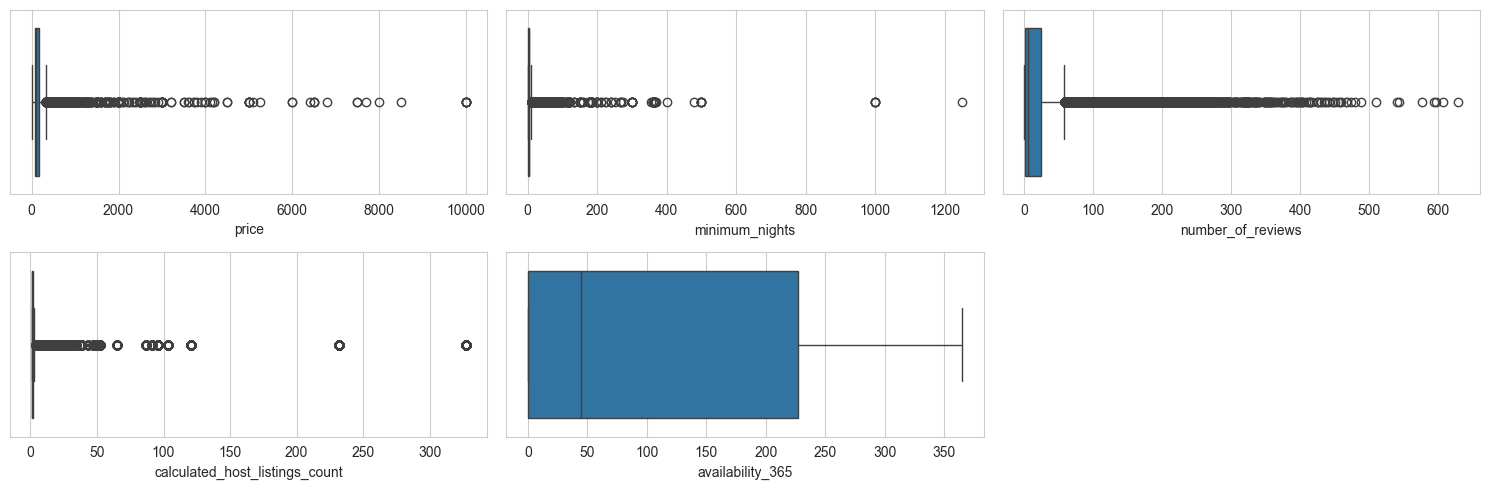

In [ ]:
fig, axis = plt.subplots(2, 3, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0, 0], data=df, x="price")
sns.boxplot(ax=axis[0, 1], data=df, x="minimum_nights")
sns.boxplot(ax=axis[0, 2], data=df, x="number_of_reviews")
sns.boxplot(ax=axis[1, 0], data=df, x="calculated_host_listings_count")
sns.boxplot(ax=axis[1, 1], data=df, x="availability_365")
fig.delaxes(axis[1, 2])

plt.tight_layout()
plt.show()

### Variables con valores atípicos

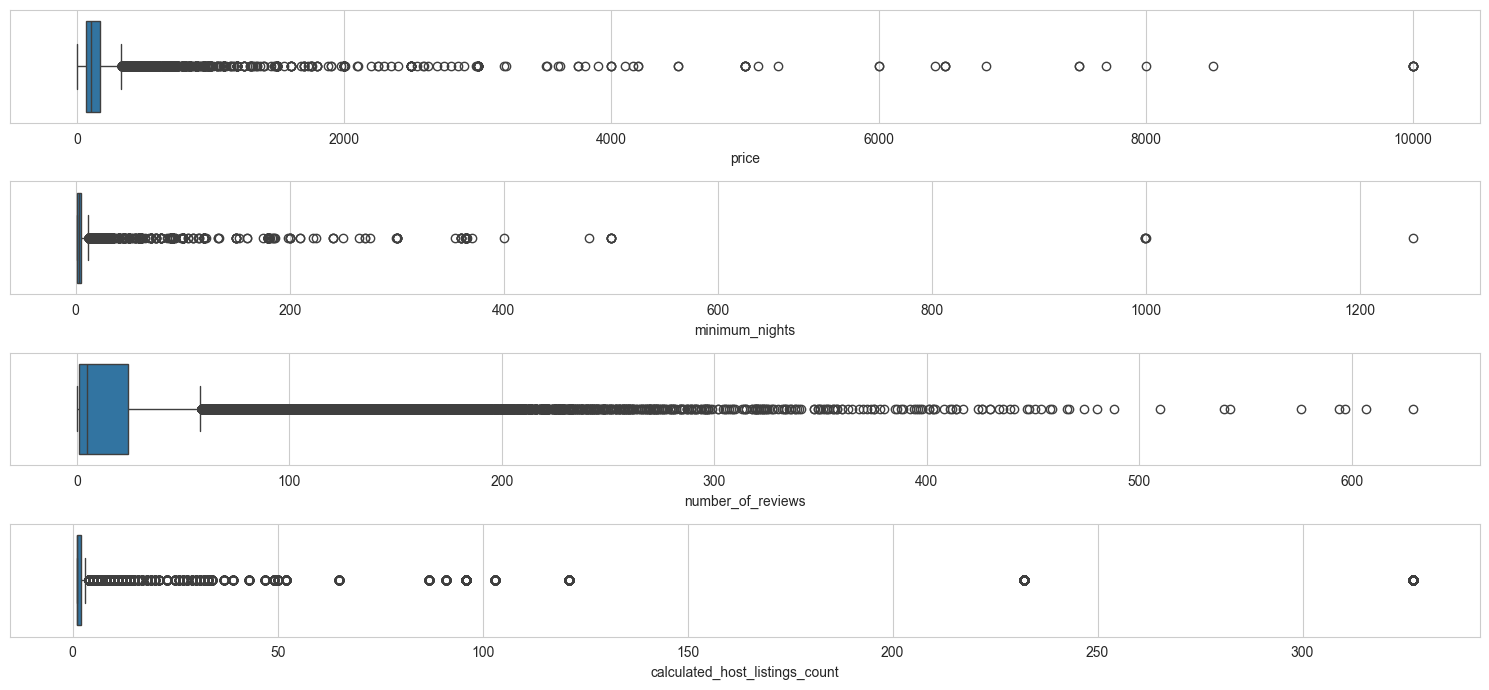

In [ ]:
fig, axis = plt.subplots(4, 1, figsize=(15, 7))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, x="price")
sns.boxplot(ax=axis[1], data=df, x="minimum_nights")
sns.boxplot(ax=axis[2], data=df, x="number_of_reviews")
sns.boxplot(ax=axis[3], data=df, x="calculated_host_listings_count")
plt.tight_layout()
plt.show()

#### Valores atípicos 'price'

In [ ]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

#### Calculo del Rango inter cuartil: IQR = Q3(75%) - Q1(25%)

In [ ]:

q1_price = df["price"].quantile(0.25)
q3_price = df["price"].quantile(0.75)
iqr_price = q3_price - q1_price

# Definir los límites inferior y superior
lower_limit_price = 0 if (q1_price - 1.5 * iqr_price) < 0 else q1_price - 1.5 * iqr_price
upper_limit_price = q3_price + 1.5 * iqr_price

f"Límite superior: {round(upper_limit_price, 2)}, Límite inferior: {round(lower_limit_price, 2)}, Rango intercuartílico: {round(iqr_price, 2)}"

'Límite superior: 334.0, Límite inferior: 0, Rango intercuartílico: 106.0'

In [ ]:
df[df['price'] > 334]

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n,price_range
61,Manhattan,40.74623,-73.99530,Entire home/apt,375,180,5,1,180,1,1,301-500
85,Brooklyn,40.69723,-73.99268,Entire home/apt,800,1,25,1,7,1,0,501-1000
103,Manhattan,40.73096,-74.00319,Entire home/apt,500,4,46,2,243,1,1,301-500
114,Manhattan,40.72540,-73.98157,Entire home/apt,350,2,7,4,298,1,1,301-500
121,Brooklyn,40.66499,-73.97925,Entire home/apt,400,2,16,2,216,1,0,301-500
...,...,...,...,...,...,...,...,...,...,...,...,...
48758,Queens,40.75508,-73.93258,Entire home/apt,350,2,0,1,364,1,2,301-500
48833,Manhattan,40.70605,-74.01042,Entire home/apt,475,2,0,1,64,1,1,301-500
48839,Brooklyn,40.59866,-73.95661,Private room,800,1,0,1,23,0,0,501-1000
48842,Manhattan,40.75204,-74.00292,Entire home/apt,350,1,0,1,9,1,1,301-500


#### Existen 2990 valores atípicos para la variable precio, pero si tenemos en cuenta que la mayoría de viviendas son apartamentos completos, tiene sentido pensar que su precio varie por las características que puedan tener, dato del que no disponemos, por lo tanto decido mantener estos valores

#### Valores atípicos 'minimum_nights'

In [ ]:
df['minimum_nights'].describe()

count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

#### Calculo del Rango inter cuartil: IQR = Q3(75%) - Q1(25%)

In [ ]:
q1_nights = df['minimum_nights'].quantile(0.25)
q3_nights = df['minimum_nights'].quantile(0.75)
iqr_nights = q3_nights - q1_nights

# Definir los límites inferior y superior
lower_limit_nights = 0 if (q1_nights - 1.5 * iqr_nights) < 0 else q1_nights - 1.5 * iqr_nights
upper_limit_nights = q3_nights + 1.5 * iqr_nights

f"Límite superior: {round(upper_limit_nights, 2)}, Límite inferior: {round(lower_limit_nights, 2)}, Rango intercuartílico: {round(iqr_nights, 2)}"

'Límite superior: 11.0, Límite inferior: 0, Rango intercuartílico: 4.0'

In [ ]:
df[df['minimum_nights']>11]

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n,price_range
6,Brooklyn,40.68688,-73.95596,Private room,60,45,49,1,0,0,0,51-100
14,Manhattan,40.73530,-74.00525,Entire home/apt,120,90,27,1,0,1,1,101-150
29,Manhattan,40.72920,-73.98542,Entire home/apt,180,14,29,1,67,1,1,151-200
36,Brooklyn,40.68876,-73.94312,Private room,35,60,0,1,365,0,0,0-50
45,Brooklyn,40.65944,-73.96238,Entire home/apt,150,29,11,1,95,1,0,101-150
...,...,...,...,...,...,...,...,...,...,...,...,...
48810,Manhattan,40.79952,-73.96003,Private room,75,30,0,1,90,0,1,51-100
48843,Brooklyn,40.69635,-73.93743,Private room,45,29,0,2,341,0,0,0-50
48871,Manhattan,40.82233,-73.94687,Private room,35,29,0,2,31,0,1,0-50
48879,Brooklyn,40.71728,-73.94394,Entire home/apt,120,20,0,1,22,1,0,101-150


#### Existen más de 6600 valores atípicos. Investigando un poco en internet, el mínimo de noches estandar es de 30 días, aunque podemos observar viviendas que alquilan por temporadas largas, 3-6 meses, incluso un año. Considero que valores por encima de un año deberían ser eliminados ya que seguramente se trate de algún error y carece de sentido.

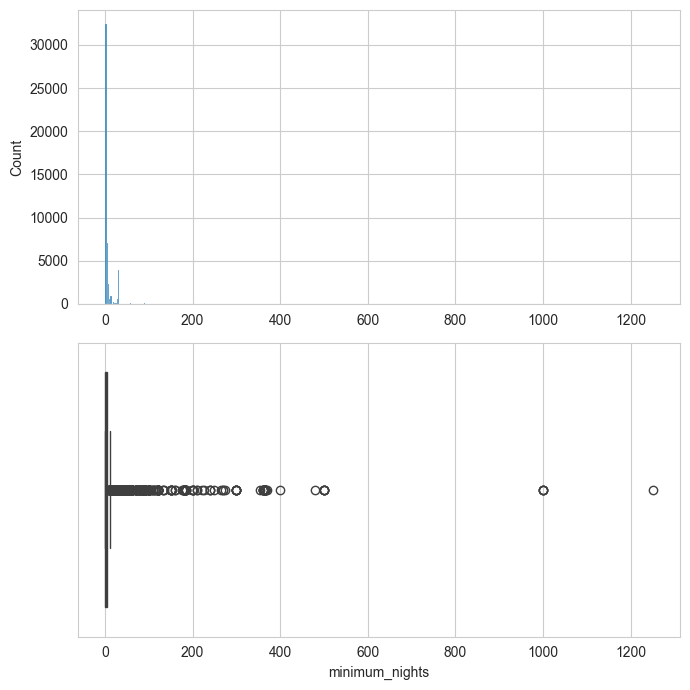

In [ ]:
fig, axis = plt.subplots(2, 1, figsize=(7, 7))
sns.set_style("whitegrid")

sns.histplot(ax=axis[0], data=df, x="minimum_nights").set(xlabel=None)
sns.boxplot(ax=axis[1], data=df, x="minimum_nights")



plt.tight_layout()
plt.show()

#### Sustituyo los valores extremos por la media de la distribución porque me parece un valor más adecuado

In [ ]:
mean_nights = df[df['minimum_nights'] <= 365]['minimum_nights'].mean()
df.loc[df['minimum_nights'] > 365, 'minimum_nights'] = int(mean_nights)
df['minimum_nights'].describe()

count    48895.000000
mean         6.840188
std         16.449667
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max        365.000000
Name: minimum_nights, dtype: float64

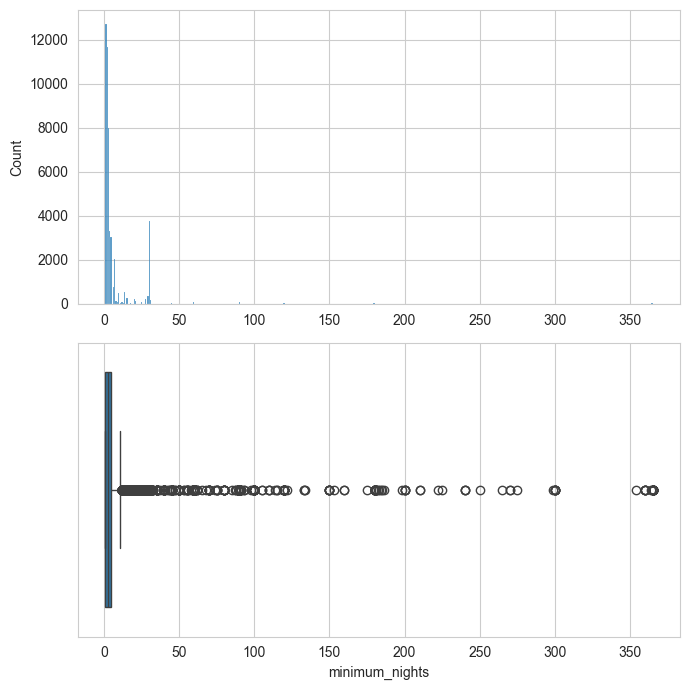

In [ ]:
fig, axis = plt.subplots(2, 1, figsize=(7, 7))
sns.set_style("whitegrid")

sns.histplot(ax=axis[0], data=df, x="minimum_nights").set(xlabel=None)
sns.boxplot(ax=axis[1], data=df, x="minimum_nights")



plt.tight_layout()
plt.show()

#### Aunque siguen existiendo valores atípicos, ahora estos siguen una tendencia más adaptada a la realidad, por lo que sí los mantenemos

#### Valores atípicos 'calculated_host_listings_count'

In [ ]:
df['calculated_host_listings_count'].describe().T

count    48895.000000
mean         7.143982
std         32.952519
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64

#### Calculo del Rango inter cuartil: IQR = Q3(75%) - Q1(25%)

In [ ]:
q1_host = df['calculated_host_listings_count'].quantile(0.25)
q3_host = df['calculated_host_listings_count'].quantile(0.75)
iqr_host = q3_host - q1_host

# Definir los límites inferior y superior
lower_limit_host = 0 if (q1_host - 1.5 * iqr_host) < 0 else q1_host - 1.5 * iqr_host
upper_limit_host = q3_host + 1.5 * iqr_host

f"Límite superior: {round(upper_limit_host, 2)}, Límite inferior: {round(lower_limit_host, 2)}, Rango intercuartílico: {round(iqr_host, 2)}"

'Límite superior: 3.5, Límite inferior: 0, Rango intercuartílico: 1.0'

In [ ]:
df.loc[df['calculated_host_listings_count']>3.5]

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n,price_range
0,Brooklyn,40.64749,-73.97237,Private room,149,1,9,6,365,0,0,101-150
9,Manhattan,40.71344,-73.99037,Entire home/apt,150,1,160,4,188,1,1,101-150
21,Brooklyn,40.68069,-73.97706,Private room,130,2,130,6,347,0,0,101-150
22,Brooklyn,40.67989,-73.97798,Private room,80,1,39,6,364,0,0,51-100
23,Brooklyn,40.68001,-73.97865,Private room,110,2,71,6,304,0,0,101-150
...,...,...,...,...,...,...,...,...,...,...,...,...
48858,Queens,40.74387,-73.82556,Private room,68,3,0,4,362,0,2,51-100
48867,Brooklyn,40.59080,-73.97116,Shared room,25,1,0,6,338,2,0,0-50
48868,Brooklyn,40.59118,-73.97119,Shared room,25,7,0,6,365,2,0,0-50
48878,Queens,40.74477,-73.87727,Private room,45,1,0,5,172,0,2,0-50


#### Observamos más de 7000 valores outliers, pero como hemos visto previamente esto se debe a que existen inmobiliarias que tienen en propiedad una gran cantidad de viviendas, lo mismo que algunos particulares. Siguiendo este razonamiento podemos mantener los valores atípicos ya que es un comportamiento bastante adecuado con la realidad.

#### La variable 'number_of_reviews' no creo que sea necesaria estudiarla, ya que podemos deducir que una vivienda tenga múltiples reseñas, además no se expresa en los datos la calidad de la reseña por lo que es intrascendente (se podría haber obviado su estudio pero quería ver si tenía alguna relación con el precio)

### Análisis de valores faltantes

In [ ]:
df.isnull().sum().sort_values(ascending=False) / len(df)

neighbourhood_group               0.0
latitude                          0.0
longitude                         0.0
room_type                         0.0
price                             0.0
minimum_nights                    0.0
number_of_reviews                 0.0
calculated_host_listings_count    0.0
availability_365                  0.0
room_type_n                       0.0
neighbourhood_group_n             0.0
price_range                       0.0
dtype: float64

#### En este caso no existen valores nulos debido a la limpieza de datos que hemos hecho previamente, así como tampoco es necesario hacer inferencia de características porque no tienen ninguna relación

## Split de datos

### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable 'price' como target

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

X_train

,neighbourhood_group,latitude,longitude,room_type,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n,price_range
18165,Manhattan,40.70741,-74.00540,Entire home/apt,1,0,1,0,1,1,201-300
3883,Brooklyn,40.61518,-73.98874,Entire home/apt,30,28,1,282,1,0,51-100
4803,Brooklyn,40.69502,-73.90645,Private room,3,225,1,15,0,0,51-100
14900,Manhattan,40.73755,-73.98041,Entire home/apt,5,1,1,0,1,1,101-150
15597,Manhattan,40.80276,-73.94976,Entire home/apt,28,53,2,310,1,1,301-500
...,...,...,...,...,...,...,...,...,...,...,...
5294,Manhattan,40.82654,-73.94620,Entire home/apt,1,10,1,297,1,1,101-150
1726,Manhattan,40.73364,-74.00539,Entire home/apt,2,68,1,63,1,1,151-200
35653,Bronx,40.84184,-73.84967,Private room,1,26,2,123,0,4,0-50
25720,Manhattan,40.72547,-73.98315,Entire home/apt,2,2,1,0,1,1,101-150


## Scaling & Encoding

### Scaling

#### Usamos el método max-min scaler porque los datos están sesgados y hay valores atípicos

#### Scaling X_train

In [ ]:
min_max_scaler = MinMaxScaler()  # Instancia de: from sklearn.preprocessing import MinMaxScaler

num_variables = ['latitude', 'longitude','minimum_nights', 'number_of_reviews', 'calculated_host_listings_count',
                 'availability_365', 'room_type_n', 'neighbourhood_group_n']
min_max_train_features = min_max_scaler.fit_transform(X_train[num_variables])

X_train_min_max = pd.DataFrame(min_max_train_features,
                               index=X_train.index,
                               columns=num_variables)
X_train_min_max

,latitude,longitude,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n
18165,0.503260,0.448137,0.000000,0.000000,0.000000,0.000000,0.5,0.25
3883,0.279699,0.479580,0.079670,0.047138,0.000000,0.772603,0.5,0.00
4803,0.473227,0.634885,0.005495,0.378788,0.000000,0.041096,0.0,0.00
14900,0.576318,0.495301,0.010989,0.001684,0.000000,0.000000,0.5,0.25
15597,0.734384,0.553146,0.074176,0.089226,0.003067,0.849315,0.5,0.25
...,...,...,...,...,...,...,...,...
5294,0.792025,0.559865,0.000000,0.016835,0.000000,0.813699,0.5,0.25
1726,0.566840,0.448156,0.002747,0.114478,0.000000,0.172603,0.5,0.25
35653,0.829112,0.742045,0.000000,0.043771,0.003067,0.336986,0.0,1.00
25720,0.547037,0.490129,0.002747,0.003367,0.000000,0.000000,0.5,0.25


#### Scaling X_test

In [ ]:
min_max_test_features = min_max_scaler.transform(X_test[num_variables])

X_test_min_max = pd.DataFrame(min_max_test_features,
                               index=X_test.index,
                               columns=num_variables)
X_test_min_max

,latitude,longitude,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n
6794,0.373114,0.499113,0.005495,0.116057,0.000000,0.328767,0.5,0.00
14429,0.525456,0.510069,0.002747,0.006359,0.003067,0.002740,0.0,0.25
46503,0.630974,0.624320,0.005495,0.000000,0.000000,0.117808,0.0,0.50
48230,0.463667,0.748949,0.000000,0.003180,0.000000,0.983562,0.0,0.50
33194,0.440329,0.575614,0.079670,0.000000,0.006135,0.536986,0.5,0.00
...,...,...,...,...,...,...,...,...
24289,0.599509,0.670730,0.000000,0.000000,0.000000,0.000000,0.0,0.50
35668,0.500657,0.579569,0.005495,0.001590,0.000000,0.000000,0.0,0.00
15878,0.395238,0.516975,0.032967,0.006359,0.000000,0.126027,0.5,0.00
17650,0.685033,0.523861,0.079670,0.001590,0.263804,0.000000,0.5,0.25


### Encoding

#### Usamos el método one-hot encoding ya que las variables a codificar no tienen un orden determinado

#### Encoding X_train

In [ ]:
# Genero una lista con los nombres de las columnas categóricas
cat_variables = ["room_type", "neighbourhood_group"]

# Creamos la instancia del encoder
onehot_encoder = OneHotEncoder(sparse_output=False)

# Entrenamos y aplicamos el encoder en el conjunto de entrenamiento: X_train
X_train_cat_ohe = onehot_encoder.fit_transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=X_train.index,
                               columns=onehot_encoder.get_feature_names_out(cat_variables))

X_train_cat_ohe.head()

,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
18165,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3883,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4803,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
14900,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15597,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


#### Encoding X_test

In [ ]:
# Entrenamos y aplicamos el encoder en el conjunto de test: X_test
X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe,
                              index=X_test.index,
                              columns=onehot_encoder.get_feature_names_out(cat_variables))
X_test_cat_ohe

,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
6794,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
14429,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
46503,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
48230,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
33194,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
24289,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
35668,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
15878,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
17650,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Guardado de scalers y encoders

In [ ]:
with open('C:/Users/Simón/sayons-intro-ml-new/data/raw/AB_NYC_2019-min-max-scaler.pkl', 'wb') as file:
    pickle.dump(min_max_scaler, file)

In [ ]:
with open('C:/Users/Simón/sayons-intro-ml-new/data/raw/AB_NYC_2019-one-hot-encoder.pkl', 'wb') as file2:
    pickle.dump(onehot_encoder, file2)